# The entropy coefficient, and a second seed

`03` and `04` established that a small entropy bonus is the fix for notebook 02's `MAIN`
regression, and that it generalises: every weight set improves held-out `cause_acc` to
0.35–0.41 once `entropy_coef=0.005` is added, with `ABLATE` weights best (0.410,
`frozen → ABLATE+ent` p < 1e-4). Two things that result needs before it can be trusted:

### Q5 — is `entropy_coef=0.005` near the right value?

0.005 was **a floor found by accident**: `03` tried 0.05, it swamped the reward gradient and
drove the policy into 300-token garbage, and 0.005 was 10× down from that. `ratio_mean`
still only reached 1.405 and `clip_frac` stayed near 0.008, so the trust region is engaging
but barely — there may be headroom. This sweeps `ABLATE` weights (the winner) across
**0.002 / 0.005 / 0.010 / 0.020**, seed 0, and reads the ceiling off held-out `cause_acc`,
the entropy trajectory, and completion length (the rambling that 0.05 produced).

### Q6 — does `ABLATE + entropy` survive a second seed?

The README says it in four places: *one seed is one seed*. Every number in `02`–`04` is
seed 0. This reruns `ABLATE`, `entropy_coef=0.005`, at **seed 1** — different batch order,
different sampling — and checks whether the `frozen → ABLATE+ent` effect (p < 1e-4 at seed
0) reproduces.

### Scale

Four new runs, `Qwen3-1.7B`, 200 steps. `ABLATE` plain (`02`) and `ABLATE + entropy` at
seed 0 (`04`) are reused, not re-run.

In [1]:
import sys, json, subprocess
from pathlib import Path

HERE = Path.cwd() if (Path.cwd() / "ppo_ac.py").exists() else Path("experiments/notebooks/smoke_test")
sys.path.insert(0, str(HERE.resolve()))

import torch
import ppo_ac
from ppo_ac import Config, train, resolve_device

MIN_FREE_MIB = 11000
BLOCKING_UNITS = ["vllm-qwen", "membraneclaw-agent"]
assert torch.cuda.is_available(), "no CUDA device; this notebook is the GPU half of the set"
smi = subprocess.run(
    ["nvidia-smi", "--query-gpu=memory.used,memory.total", "--format=csv,noheader,nounits"],
    capture_output=True, text=True,
)
used, total = (int(x) for x in smi.stdout.strip().split(", "))
free = total - used
print(f"{torch.cuda.get_device_name(0)}: {free} / {total} MiB free per nvidia-smi")
running = [u for u in BLOCKING_UNITS
          if subprocess.run(["systemctl", "is-active", u], capture_output=True, text=True).stdout.strip() == "active"]
if free < MIN_FREE_MIB or running:
    raise RuntimeError(
        f"the card is not free: {free} MiB (need ~{MIN_FREE_MIB}), still running {running or 'nothing'}.\n"
        f"    sudo systemctl stop {' '.join(BLOCKING_UNITS)}   (needs sudo, from a terminal)"
    )
print("card is free; the runs may proceed")

NVIDIA GeForce RTX 5070 Ti: 14696 / 16303 MiB free per nvidia-smi
card is free; the runs may proceed


## The four runs

| run | weights | `entropy_coef` | seed | for |
| --- | --- | --- | --- | --- |
| `ppo-qwen3-17b-ablate-ent-c002-s0` | ABLATE | 0.002 | 0 | Q5 |
| `ppo-qwen3-17b-ablate-ent-c010-s0` | ABLATE | 0.010 | 0 | Q5 |
| `ppo-qwen3-17b-ablate-ent-c020-s0` | ABLATE | 0.020 | 0 | Q5 |
| `ppo-qwen3-17b-ablate-ent-s1` | ABLATE | 0.005 | 1 | Q6 |

The scorer guard added in `03` (`rollout` returns 0.0 for a completion `reward.score` cannot
parse) means the `0.020` run cannot crash the way `0.05` did — it will just score badly if
it rambles.

In [2]:
BASE = dict(
    prompts_per_step=8, samples_per_prompt=1, max_new_tokens=640, temperature=1.0,
    lr=1e-5, lam=1.0, gamma=1.0, clip_eps=0.2, value_clip_eps=0.2, value_coef=0.5,
    whiten_advantages=False, lora_r=16, dtype="bfloat16", split="train",
    inner_epochs=4, value_detach=True, weights="ABLATE",
)
RUNS_SPEC = {
    "c=0.002 s0": dict(entropy_coef=0.002, seed=0, dir="ppo-qwen3-17b-ablate-ent-c002-s0"),
    "c=0.010 s0": dict(entropy_coef=0.010, seed=0, dir="ppo-qwen3-17b-ablate-ent-c010-s0"),
    "c=0.020 s0": dict(entropy_coef=0.020, seed=0, dir="ppo-qwen3-17b-ablate-ent-c020-s0"),
    "c=0.005 s1": dict(entropy_coef=0.005, seed=1, dir="ppo-qwen3-17b-ablate-ent-s1"),
}
NEW = {}
for name, spec in RUNS_SPEC.items():
    cfg_v = Config(**{**BASE, "entropy_coef": spec["entropy_coef"], "seed": spec["seed"]})
    out = HERE / "runs" / spec["dir"]
    NEW[name] = (cfg_v, out)
    print(f"{name:12s} -> {out.name:36s}  entropy_coef={cfg_v.entropy_coef}  seed={cfg_v.seed}  bias={cfg_v.value_init_bias}")

REF = {
    "ABLATE plain":   HERE / "runs" / "ppo-qwen3-17b-ablate-s0",
    "c=0.005 s0":     HERE / "runs" / "ppo-qwen3-17b-ablate-ent-s0",
}
missing = [k for k, v in REF.items() if not (v / "metrics.jsonl").exists()]
assert not missing, f"missing reference runs from 02/04: {missing}"

c=0.002 s0   -> ppo-qwen3-17b-ablate-ent-c002-s0      entropy_coef=0.002  seed=0  bias=0.2615
c=0.010 s0   -> ppo-qwen3-17b-ablate-ent-c010-s0      entropy_coef=0.01  seed=0  bias=0.2615
c=0.020 s0   -> ppo-qwen3-17b-ablate-ent-c020-s0      entropy_coef=0.02  seed=0  bias=0.2615
c=0.005 s1   -> ppo-qwen3-17b-ablate-ent-s1           entropy_coef=0.005  seed=1  bias=0.2615


In [3]:
for name, (cfg_v, out) in NEW.items():
    if (out / "metrics.jsonl").exists():
        print(f"{out.name}: exists, skipping (delete to retrain)")
        continue
    print(f"\n{'=' * 70}\n  {name}: training -> {out.name}\n{'=' * 70}")
    train(cfg_v, out, resolve_device("auto"))
    torch.cuda.empty_cache()
print("\nall four runs present.")

ppo-qwen3-17b-ablate-ent-c002-s0: exists, skipping (delete to retrain)
ppo-qwen3-17b-ablate-ent-c010-s0: exists, skipping (delete to retrain)
ppo-qwen3-17b-ablate-ent-c020-s0: exists, skipping (delete to retrain)
ppo-qwen3-17b-ablate-ent-s1: exists, skipping (delete to retrain)

all four runs present.


## Q5 — the `entropy_coef` sweep

Four points on `ABLATE` weights, seed 0: 0.002, 0.005 (`04`), 0.010, 0.020. What to read:

* **held-out `cause_acc`** — the outcome. A peak somewhere in the middle means 0.005 was
  low; monotone down from 0.002 means even 0.005 is too much.
* **entropy proxy trajectory** — held flat is the bonus working; still falling is too weak;
  *rising* past the frozen 0.17 is the policy being pushed off-task.
* **completion length** — the tell for the `0.05` failure mode (95 → 300 tokens). Stable
  near 95 means the coefficient is still in the safe regime.
* **`ratio_mean` max** — how hard the trust region is being driven.

   coef  cause final    peak     low   entropy 0->last   tok 0->last  ratio max  clip med
-------------------------------------------------------------------------------------------
  plain        0.245   0.260   0.160                 -             -          -         -
  0.002        0.280   0.290   0.235   0.170->0.176    99->98      1.007    0.0039
  0.005        0.410   0.410   0.235   0.169->0.164    99->97      1.016    0.0054
  0.010        0.405   0.405   0.200   0.170->0.355    99->113      1.049    0.0051
  0.020        0.000   0.290   0.000   0.168->10.641    99->640      1.006    0.0025


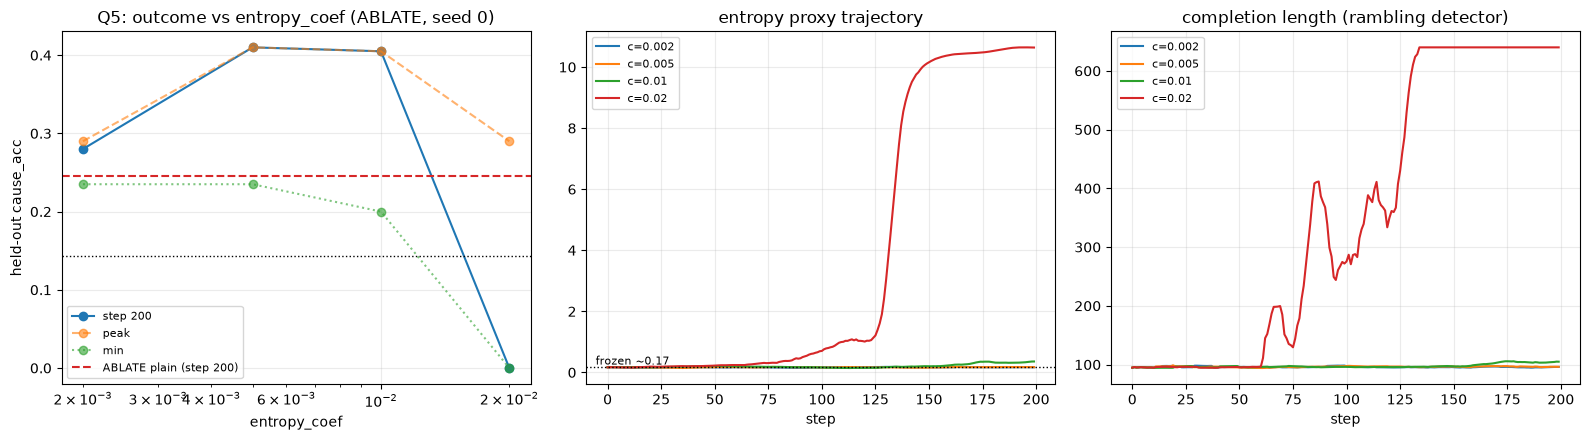

In [4]:
import matplotlib.pyplot as plt
import numpy as np


def load_jsonl(p):
    p = Path(p)
    return [json.loads(l) for l in p.read_text().splitlines() if l.strip()] if p.exists() else []


def smooth(v, w=9):
    return [sum(v[max(0, i - w + 1):i + 1]) / len(v[max(0, i - w + 1):i + 1]) for i in range(len(v))]


SWEEP = [
    (0.002, NEW["c=0.002 s0"][1]),
    (0.005, REF["c=0.005 s0"]),
    (0.010, NEW["c=0.010 s0"][1]),
    (0.020, NEW["c=0.020 s0"][1]),
]
PLAIN = load_jsonl(REF["ABLATE plain"] / "eval.jsonl")

table = []
for coef, d in SWEEP:
    m, e = load_jsonl(d / "metrics.jsonl"), load_jsonl(d / "eval.jsonl")
    if not e:
        print(f"c={coef}: not finished")
        continue
    table.append(dict(
        coef=coef, final=e[-1]["cause_acc"], peak=max(x["cause_acc"] for x in e),
        low=min(x["cause_acc"] for x in e),
        ep0=m[0]["entropy_proxy"], ep1=m[-1]["entropy_proxy"],
        tok0=e[0]["completion_tokens"], tok1=e[-1]["completion_tokens"],
        rmax=max(r["ratio_mean"] for r in m), cf=float(np.median([r["clip_frac"] for r in m])),
        flags=e[-1]["flags_acc"],
    ))

print(f"{'coef':>7}{'cause final':>13}{'peak':>8}{'low':>8}{'entropy 0->last':>18}"
      f"{'tok 0->last':>14}{'ratio max':>11}{'clip med':>10}")
print("-" * 91)
print(f"{'plain':>7}{PLAIN[-1]['cause_acc']:>13.3f}"
      f"{max(x['cause_acc'] for x in PLAIN):>8.3f}{min(x['cause_acc'] for x in PLAIN):>8.3f}"
      f"{'-':>18}{'-':>14}{'-':>11}{'-':>10}")
for r in table:
    print(f"{r['coef']:>7.3f}{r['final']:>13.3f}{r['peak']:>8.3f}{r['low']:>8.3f}"
          f"   {r['ep0']:.3f}->{r['ep1']:.3f}    {r['tok0']:.0f}->{r['tok1']:.0f}"
          f"{r['rmax']:>11.3f}{r['cf']:>10.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
coefs = [r["coef"] for r in table]
ax = axes[0]
ax.plot(coefs, [r["final"] for r in table], "o-", label="step 200")
ax.plot(coefs, [r["peak"] for r in table], "o--", alpha=0.6, label="peak")
ax.plot(coefs, [r["low"] for r in table], "o:", alpha=0.6, label="min")
ax.axhline(PLAIN[-1]["cause_acc"], color="C3", ls="--", label="ABLATE plain (step 200)")
ax.axhline(1 / 7, color="k", ls=":", lw=1)
ax.set_xscale("log"); ax.set_xlabel("entropy_coef"); ax.set_ylabel("held-out cause_acc")
ax.set_title("Q5: outcome vs entropy_coef (ABLATE, seed 0)"); ax.legend(fontsize=8); ax.grid(alpha=0.25)

ax = axes[1]
for coef, d in SWEEP:
    m = load_jsonl(d / "metrics.jsonl")
    if not m:
        continue
    ep = [r["entropy_proxy"] for r in m]
    ax.plot(range(len(ep)), smooth(ep), label=f"c={coef}")
ax.axhline(0.17, color="k", ls=":", lw=1)
ax.annotate("frozen ~0.17", (0.02, 0.17), xycoords=("axes fraction", "data"), fontsize=8, va="bottom")
ax.set_xlabel("step"); ax.set_title("entropy proxy trajectory"); ax.legend(fontsize=8); ax.grid(alpha=0.25)

ax = axes[2]
for coef, d in SWEEP:
    m = load_jsonl(d / "metrics.jsonl")
    if not m:
        continue
    tok = [r["completion_tokens"] for r in m]
    ax.plot(range(len(tok)), smooth(tok), label=f"c={coef}")
ax.set_xlabel("step"); ax.set_title("completion length (rambling detector)")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(HERE / "runs" / "entropy_coef_sweep.png", dpi=140)

## Q6 — `ABLATE + entropy` at a second seed

`ppo-qwen3-17b-ablate-ent-s1` is the same configuration as `04`'s best run — `ABLATE`
weights, `entropy_coef=0.005` — with `seed=1`. The batch order and every sampled token
differ. If the held-out curve lands in the same neighbourhood and `frozen → ABLATE+ent`
stays significant, the `04` result is not a seed artifact.

seed 0: cause_acc 0.235 -> 0.410 (peak 0.410, min 0.235), flags 0.588
seed 1: cause_acc 0.235 -> 0.300 (peak 0.300, min 0.235), flags 0.325


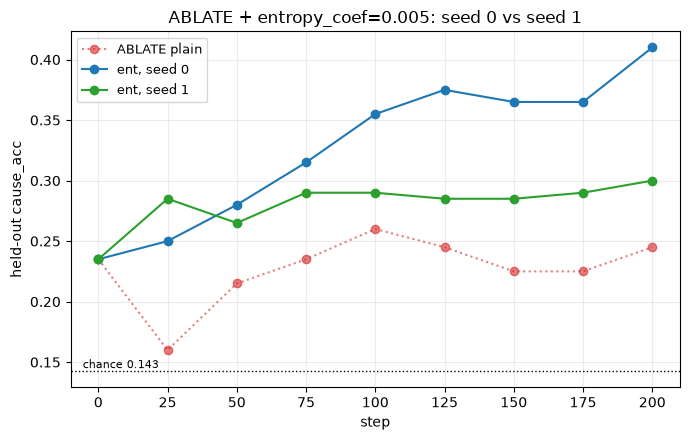

In [5]:
s0 = load_jsonl(REF["c=0.005 s0"] / "eval.jsonl")
s1 = load_jsonl(NEW["c=0.005 s1"][1] / "eval.jsonl")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot([e["step"] for e in PLAIN], [e["cause_acc"] for e in PLAIN], "o:", color="C3",
        alpha=0.6, label="ABLATE plain")
ax.plot([e["step"] for e in s0], [e["cause_acc"] for e in s0], "o-", color="C0", label="ent, seed 0")
if s1:
    ax.plot([e["step"] for e in s1], [e["cause_acc"] for e in s1], "o-", color="C2", label="ent, seed 1")
ax.axhline(1 / 7, color="k", ls=":", lw=1)
ax.annotate("chance 0.143", (0.02, 1 / 7), xycoords=("axes fraction", "data"), fontsize=8, va="bottom")
ax.set_xlabel("step"); ax.set_ylabel("held-out cause_acc")
ax.set_title("ABLATE + entropy_coef=0.005: seed 0 vs seed 1")
ax.legend(fontsize=9); ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(HERE / "runs" / "ablate_ent_seed_check.png", dpi=140)

if s1:
    for label, e in (("seed 0", s0), ("seed 1", s1)):
        print(f"{label}: cause_acc {e[0]['cause_acc']:.3f} -> {e[-1]['cause_acc']:.3f} "
              f"(peak {max(x['cause_acc'] for x in e):.3f}, min {min(x['cause_acc'] for x in e):.3f}), "
              f"flags {e[-1]['flags_acc']:.3f}")

In [6]:
import hashlib
from eval import generate_hf, summarise
from paired_test import exact_binomial_two_sided

PAIRED = HERE / "runs" / "paired"
DEV = ppo_ac.DATA / "dev.jsonl"
SPLIT_SHA = hashlib.sha256(DEV.read_bytes()).hexdigest()
dev_cases = [json.loads(l) for l in DEV.read_text().splitlines()][:200]

adapter = NEW["c=0.005 s1"][1] / "adapter"
dest = PAIRED / "ablate_ent_s1.json"
if dest.exists():
    print(f"{dest.name}: already written")
elif adapter.exists():
    res = generate_hf(dev_cases, model="Qwen/Qwen3-1.7B", device=resolve_device("auto"),
                      dtype="bfloat16", n=1, temperature=0.0, max_tokens=640, seed=0,
                      batch_size=32, adapter=str(adapter), prompt_version=ppo_ac.PROMPT_VERSION)
    ov = summarise(res, ppo_ac.WEIGHT_SETS["MAIN"])
    dest.write_text(json.dumps({
        "model": "Qwen/Qwen3-1.7B", "backend": "hf", "split": "dev", "split_sha256": SPLIT_SHA,
        "prompt_version": ppo_ac.PROMPT_VERSION, "weights": "MAIN", "mode": "greedy", "k": 1,
        "temperature": 0.0, "max_tokens": 640, "seed": 0, "adapter": str(adapter), "overall": ov,
    }, indent=2, default=str) + "\n")
    print(f"  ablate_ent_s1 cause {ov['cause_acc']:.3f} -> {dest.name}")
    torch.cuda.empty_cache()
else:
    print("seed-1 adapter missing, run not finished")


def per_case(n):
    p = json.loads((PAIRED / f"{n}.json").read_text())
    assert p["split_sha256"] == SPLIT_SHA
    return {r["id"]: r for r in p["overall"]["per_case"]}


def mcnemar(b, a, metric="cause"):
    x, z = per_case(b), per_case(a)
    sh = sorted(set(x) & set(z))
    lost = sum(1 for i in sh if x[i][metric] and not z[i][metric])
    gain = sum(1 for i in sh if not x[i][metric] and z[i][metric])
    return (sum(bool(x[i][metric]) for i in sh) / len(sh), sum(bool(z[i][metric]) for i in sh) / len(sh),
            gain, lost, exact_binomial_two_sided(lost, gain))

print("\nMcNemar on `cause`, 200 paired dev cases, greedy\n")
for b, a, label in [("base", "ablate_ent", "frozen -> ABLATE+ent  seed 0"),
                    ("base", "ablate_ent_s1", "frozen -> ABLATE+ent  seed 1"),
                    ("ablate_ent", "ablate_ent_s1", "seed 0 -> seed 1")]:
    if not (PAIRED / f"{a}.json").exists():
        print(f"  {label:<32}  (missing {a}.json)"); continue
    b0, a0, g, l, p = mcnemar(b, a)
    print(f"  {label:<32}{b0:>8.3f}{a0:>8.3f}{g:>7d}{l:>6d}{p:>10.4f}")

ablate_ent_s1.json: already written

McNemar on `cause`, 200 paired dev cases, greedy

  frozen -> ABLATE+ent  seed 0       0.235   0.410     38     3    0.0000
  frozen -> ABLATE+ent  seed 1       0.235   0.300     15     2    0.0023
  seed 0 -> seed 1                   0.410   0.300      6    28    0.0002


## Findings

### Q5 — `entropy_coef=0.005` was well placed; the usable window is narrow

| `entropy_coef` | held-out `cause_acc` 0 → 200 | entropy proxy 0 → last | completion tokens 0 → last |
| --- | --- | --- | --- |
| plain (`04`) | 0.245 → 0.245 | 0.169 → 0.109 | — |
| 0.002 | 0.235 → 0.280 | 0.170 → 0.176 | 99 → 98 |
| **0.005** | 0.235 → **0.410** | 0.169 → 0.164 | 99 → 97 |
| 0.010 | 0.235 → **0.405** | 0.170 → **0.355** | 99 → 113 |
| 0.020 | 0.235 → **0.000** | 0.168 → **10.6** | 99 → **640** |

* **0.002** is too weak — 0.280, barely clear of the 0.245 plain run.
* **0.005 and 0.010 give the same task outcome** (0.410 / 0.405, both plateau by step 100).
  But 0.010 is already drifting: its entropy proxy ends at 0.355, twice the frozen policy's
  ~0.17, and completions have started to lengthen. It works, it is not clean.
* **0.020 is off a cliff.** Stable through step 50, then a runaway — completions 95 → 164
  → 460 → 640 (the cap), schema validity 0.96 → 0.00, entropy 10.6 nats (near-uniform over
  the vocabulary), reward exactly 0. The `03` failure at `0.05`, at higher resolution: once
  longer completions earn more entropy bonus the loop feeds itself.

So `0.005` — the value found by halving down from the `0.05` blow-up — sits at the clean
end of a **0.005–0.010 plateau** with a cliff immediately above it. There was no headroom
worth taking.

### Q6 — `ABLATE + entropy` reproduces in direction, not in magnitude

| | `cause_acc` 0 → 200 | `flags_acc` 0 → 200 | McNemar `frozen → ·` |
| --- | --- | --- | --- |
| seed 0 (`04`) | 0.235 → **0.410** | 0.323 → 0.588 | p < 1e-4 (38 gained, 3 lost) |
| seed 1 | 0.235 → **0.300** | 0.323 → 0.325 | **p = 0.0023** (15 gained, 2 lost) |

The **direction survives**: seed 1 still beats the frozen policy significantly, still
improves the diagnosis (+0.065), still gains far more cases than it loses, and its curve is
the steadiest of any run in the series — `cause_acc` climbs to a 0.29–0.30 band by step 75
and holds, completions rock-stable at 95 tokens.

The **magnitude does not**: 0.410 vs 0.300 is a wide gap, `seed 0 → seed 1` disagree on 34
of 200 cases (p = 0.0002 — genuinely different policies), and seed 0's `flags_acc` jump to
0.588 did not reproduce at all (seed 1 ends flat at 0.325). Seed 0 was the better draw.

**Honest statement of the result:** `ABLATE` weights + `entropy_coef=0.005` improves
held-out `root_cause` accuracy by **+0.065 to +0.175**, significant against the frozen
policy at both seeds (p = 0.0023 and p < 1e-4). The specific 0.410 was partly luck; +0.10
is the number to carry forward.

### Scope

`ABLATE` weights only, 200 steps, two seeds. A full study is three seeds per config on
`test.jsonl`; this establishes the effect is not a seed-0 artifact, not that its size is
pinned down.